In [1]:
from biosteam import main_flowsheet as F
import biosteam as bst
import thermosteam as tmo
import pandas as pd
import numpy as np


from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.settings.process_params import feed_parameters
from lignin_saf.settings.prices import prices
from lignin_saf.settings.tea_params import operating_days, labor
from lignin_saf.systems.rcf import create_rcf_system
from lignin_saf.systems.rcf_oil_purification import create_rcf_oil_purification_system
from lignin_saf.systems.monomer_purification import create_monomer_purification_system
from lignin_saf.systems.hdo import create_hdo_system
from lignin_saf.systems.cellulosic_ethanol_no_preatreatment import create_cellulosic_ethanol_system
from atj_saf.atj_bst.etj_ligfirst import create_etj_system_no_facilities
from lignin_saf.cellulosic_tea import create_cellulosic_ethanol_tea

from lignin_saf.ligsaf_units import HydrogenStorageTank




chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 840   # 2026 basis. CEPCI 
bst.settings.electricity_price = prices['electricity']

# Poplar group must be defined before creating any stream that references it
chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

# ── Area 200: RCF process ──────────────────────────────────────────────────
rcf_system = create_rcf_system(ins=poplar_in)
rcf_system.simulate()

# ── Area 300: Purification ─────────────────────────────────────────────────
rcf_oil_purification_sys = create_rcf_oil_purification_system(ins=F.RCF_CRUDE_OUT)
monomer_purification_sys = create_monomer_purification_system(ins=F.PURE_OIL_OUT)
rcf_oil_purification_sys.simulate()
monomer_purification_sys.simulate()

# ── Area 400: Hydrodeoxygenation ───────────────────────────────────────────
hdo_system = create_hdo_system(ins=F.MON_MONOMERS_OUT)
hdo_system.simulate()

etoh_system = create_cellulosic_ethanol_system(ins=F.Carbohydrate_Pulp, add_denaturant=False)
etoh_system.simulate()

# No pretreatment_wastewater — only S401 stillage filtrate goes to WWT.
etoh_ww     = [F.unit.S401.outs[1]]
etoh_solids = [F.unit.S401.outs[0]]

# Removing the NH3 fraction of the ethanol output - in the future CBP will remove this anyways, so I've just modelled it as a splitter
nh3_splitter = bst.units.Splitter(ins = F.T703.outs[0], split = {'NH3':1.0} )
nh3_splitter.simulate()

# Ethanol to Jet system
etj_system = create_etj_system_no_facilities(ins = nh3_splitter.outs[1])
etj_system.simulate()


WWT = bst.create_conventional_wastewater_treatment_system('WWT', ins=[F.WW_10, F.WastePulp, F.RCF_WW_OUTS, F.WW_11, F.WW_12, F.HDO_WW, F.HDO_wash_water, F.ETJ_WW_OUTS] + etoh_ww)

for unit in WWT.units:
    if hasattr(unit, 'strict_moisture_content'):
        unit.strict_moisture_content = False

F.unit.PWC.ins[0] = WWT.outs[2]

solids_to_BT = bst.Mixer('MIX_BT_solids', ins=[WWT.outs[1]] + etoh_solids)


BT = bst.facilities.BoilerTurbogenerator('BT', fuel_price=prices['CH4'])


gas_mixer= bst.Mixer('MIX_BT_gas', ins=(WWT.outs[0], F.RCF_PSAWASTE_OUTS, F.HDO_purge_gases, F.ETJ_PSAWASTE_OUTS))

BT.ins[0] = solids_to_BT.outs[0]  # Connecting sludge to BT solids feed
BT.ins[1] = gas_mixer.outs[0]   # Connecting biogas from WW treatment and PSA waste gases from RCF


combined_saf = bst.units.Mixer(ins = (F.ETJ_SAF_OUT, F.HDO_CYCLOALKANES_OUT), outs = 'TOTAL_SAF', rigorous = True)

h2_rcf = bst.Stream()
h2_rcf.copy_like(F.RCF_H2_IN)

h2_hdo = bst.Stream()
h2_hdo.copy_like(F.HDO_H2_IN)

h2_etj = bst.Stream()
h2_etj.copy_like(F.ETJ_H2_IN)

# Shared H2 storage — sized from combined ETJ + HDO fresh H2 demand
h2_feed_mixer = bst.Mixer('H2_FEED_MIX', ins=(h2_rcf, h2_hdo, h2_etj))
shared_h2_storage = HydrogenStorageTank('H2_TK', ins=h2_feed_mixer.outs[0])


rcf_pure_mon_hdo_etoh_etj_system = bst.System(
    'RCF+HDO+Cellulosic_ETJ',
    path=(rcf_system, rcf_oil_purification_sys, monomer_purification_sys, hdo_system, etoh_system, etj_system, combined_saf, WWT),
    facilities=[solids_to_BT, gas_mixer, h2_feed_mixer, shared_h2_storage, BT],
)

rcf_pure_mon_hdo_etoh_etj_system.simulate()

F.ETJ_H2_IN.price = prices['hydrogen']   # 8.46 USD/kg
F.ETJ_RN_OUT.price = prices['renewable_naphtha']   # 0.71 USD/kg
F.ETJ_RD_OUT.price = prices['renewable_diesel']    # 1.888 USD/kg
#F.sulfuric_acid.price = prices['H2SO4']
#F.ammonia.price = prices['NH3']
F.cellulase.price = prices['Cellulase'] 
F.CSL.price = prices ['CSL'] 
F.DAP.price = prices['DAP'] 
F.caustic.price = prices['Caustic']
F.denaturant.price =  prices['Denaturant'] 
F.cooling_tower_chemicals.price = prices['CT_chemicals'] 
#F.FGD_lime.price = prices['FOD_lime']
#F.boiler_chemicals.price = prices['Boiler_chemicals'] 


integrated_tea = create_cellulosic_ethanol_tea(rcf_pure_mon_hdo_etoh_etj_system)



integrated_tea.labor_cost = labor
integrated_tea.operating_days = 330
mjsp = round(((integrated_tea.solve_price(F.TOTAL_SAF)*F.TOTAL_SAF.rho)/264.172),2)

#print(f'The MSP for SAF blend is  {mjsp} USD/gal')




c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Hydrogen has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Methane has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\dew_point.py:129: RuntimeWarning: Methane has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (2.45e+03 hp), head (3.35e+03 ft), kinematic viscosity (6.09e-07 m2/s), and NPSH (0.745 ft); assuming centrigugal pump
  warn(f'{repr

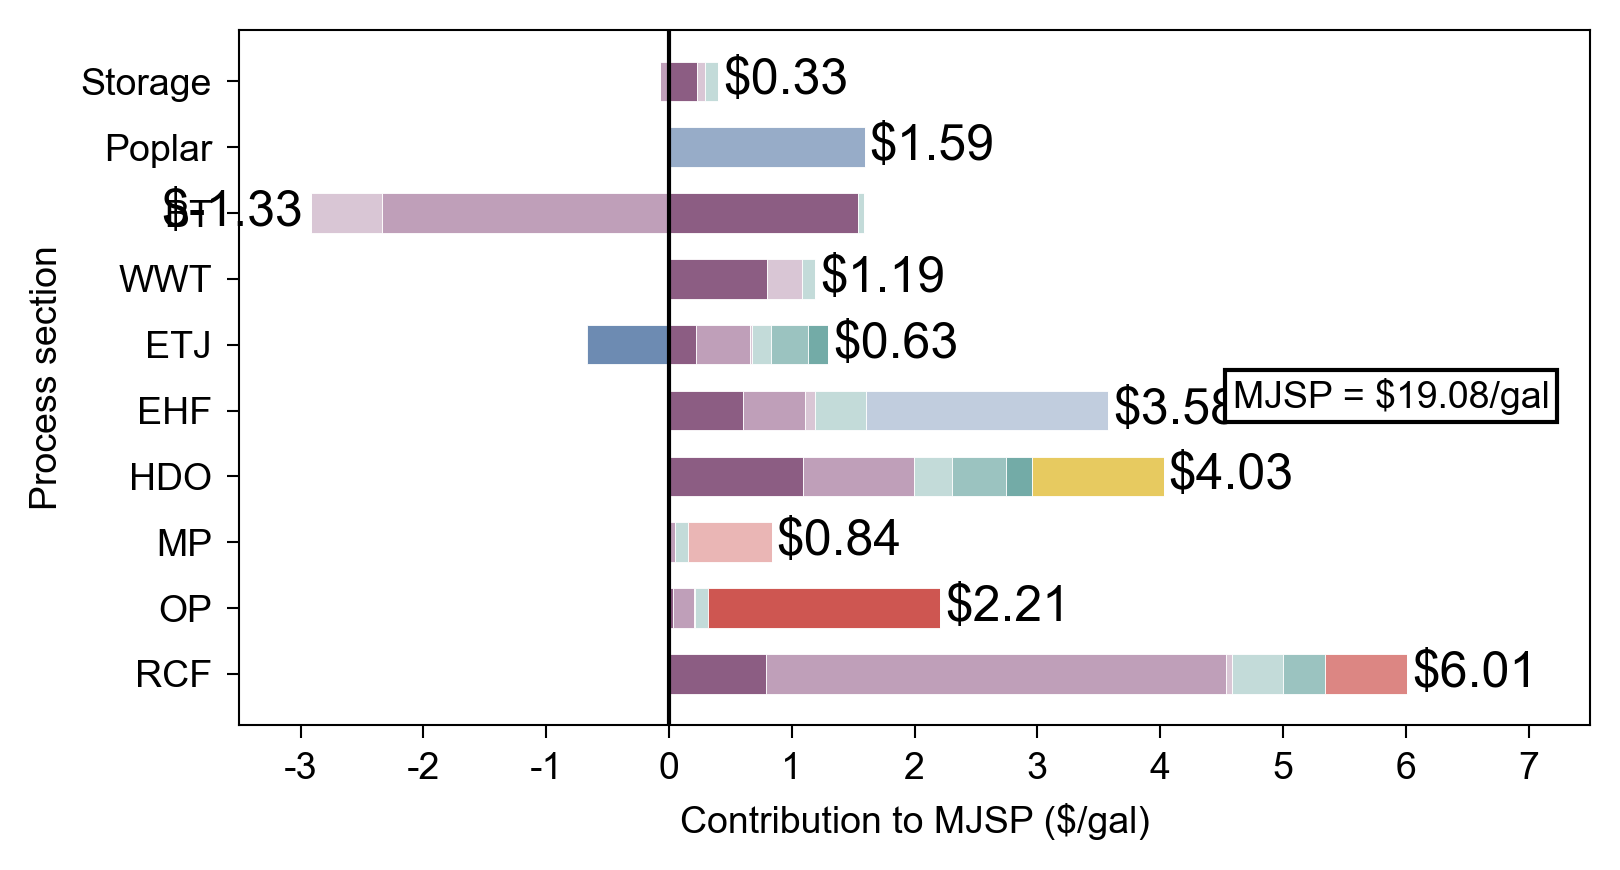

In [2]:
# ── Section unit lists ─────────────────────────────────────────────────────────
# Bar order (indices 0–9): RCF, OP, MP, HDO, EHF, ETJ, WWT, BT, Poplar, Storage

rcf_units = [F.MIX100, F.RCF_PUMP1, F.RCF_HX1, F.RCF_RXR1, F.RCF_MIX2, F.RCF_HX2,
             F.RCF_RXR2, F.RCF_FLSH1, F.RCF_COMP1, F.RCF_FLSH2, F.RCF_HX3, F.RCF_PSA1,
             F.RCF_PUMP2, F.RCF_COL1, F.RCF_COL2, F.RCF_MIX3, F.RCF_HX4, F.RCF_FLSH3,
             F.RCF_MIX4, F.RCF_FLSH4]
op_units  = [F.MIX200, F.LLE200, F.FLASH201, F.HX202, F.CENT203]
mp_units  = [F.MIX300, F.LLE300, F.FLASH301, F.HX302, F.CENT303]
hdo_units = [F.HDO_MIX1, F.HDO_MIX2, F.HDO_MIX3, F.HDO_COMP1, F.HDO_HX1, F.HDO_RXR1,
             F.HDO_HX2, F.HDO_V1, F.HDO_FLSH1, F.HDO_FLSH2, F.HDO_HX3, F.HDO_PSA1,
             F.HDO_COMP_H2, F.HDO_COL1, F.HDO_HX_DOD, F.HDO_COL2, F.HDO_HX4, F.HDO_TK1]
ehf_units = [F.M301, F.H301, F.R301, F.DAP_storage, F.S301, F.CSL_storage, F.S302,
             F.R303, F.R302, F.T301, F.M304, F.D401, F.M401, F.T302, F.P401, F.H401,
             F.D402, F.P401, F.D403, F.H402, F.U401, F.H403, F.T701, F.P701, F.T702,
             F.P702, F.M701, F.T703, F.P403, F.M1, F.S401]
etj_units = [F.ETJ_MIX1, F.ETJ_PUMP1, F.ETJ_HX1, F.ETJ_MIX2, F.ETJ_HX2, F.ETJ_RXR1,
             F.ETJ_SPLIT1, F.ETJ_FLSH1, F.ETJ_COMP1, F.ETJ_COL1, F.ETJ_COMP2, F.ETJ_COL2,
             F.ETJ_HX3, F.ETJ_MIX3, F.ETJ_RXR2, F.ETJ_SPLIT2, F.ETJ_MIX4, F.ETJ_HX4,
             F.ETJ_RXR3, F.ETJ_HX5, F.ETJ_FLSH2, F.ETJ_SPLIT3, F.ETJ_COL3, F.ETJ_COL4,
             F.ETJ_HX6, F.ETJ_HX7, F.ETJ_HX8, F.ETJ_TK1, F.ETJ_TK2, F.ETJ_TK3,
             F.ETJ_WW_MIX, F.ETJ_CAT_MIX]
storage_units = [F.CWP, F.CT, F.FWT, F.ADP, F.PWC, F.H2_TK]

op_hours = integrated_tea.operating_hours
e_price  = bst.settings.electricity_price


def _ic(units):
    return sum(u.installed_cost for u in units)

def _elec(units):
    return sum(u.power_utility.power for u in units) * e_price * op_hours

def _util(units):
    return sum(u.utility_cost if u.utility_cost is not None else 0.0 for u in units) * op_hours


# ── Installed costs ($/plant) ─────────────────────────────────────────────────
ic = np.array([
    _ic(rcf_units),
    _ic(op_units),
    _ic(mp_units),
    _ic(hdo_units),
    _ic(ehf_units),
    _ic(etj_units),
    F.WWTC.installed_cost,
    F.BT.installed_cost,
    0.0,                    # Poplar — no capital
    _ic(storage_units),
])

# ── Electricity ($/yr) ───────────────────────────────────────────────────────
elec = np.array([
    _elec(rcf_units),
    _elec(op_units),
    _elec(mp_units),
    _elec(hdo_units),
    _elec(ehf_units),
    _elec(etj_units),
    F.WWTC.power_utility.power * e_price * op_hours,
    F.BT.power_utility.power  * e_price * op_hours,
    0.0,
    _elec(storage_units),
])

# ── Utilities excl. electricity ($/yr) ───────────────────────────────────────
util = np.array([
    _util(rcf_units),
    _util(op_units),
    _util(mp_units),
    _util(hdo_units),
    _util(ehf_units),
    _util(etj_units),
    F.WWTC.utility_cost * op_hours,
    F.BT.utility_cost   * op_hours,
    0.0,
    _util(storage_units),
])
util -= elec  # remove electricity double-count

# ── Fixed costs ($/yr) — operator-ratio allocation ───────────────────────────
# Operator counts: RCF=8, OP=2, MP=2, HDO=6, EHF=8, ETJ=3, WWT=2, BT=1, Poplar=0, Storage=2
foc = integrated_tea.FOC
fc = foc * np.array([8, 2, 2, 6, 8, 3, 2, 1, 0, 2]) / 34.0

# ── Hydrogen ($/yr) — sectoral ────────────────────────────────────────────────
h2 = np.zeros(10)
h2[0] = F.RCF_H2_IN.F_mass * F.RCF_H2_IN.price * op_hours
h2[3] = F.HDO_H2_IN.F_mass * F.HDO_H2_IN.price * op_hours
h2[5] = F.ETJ_H2_IN.F_mass * F.ETJ_H2_IN.price * op_hours

# ── Catalyst replacement ($/yr) — sectoral ───────────────────────────────────
cat = np.zeros(10)
cat[0] = F.RCF_CAT_IN.F_mass * prices['NiC_catalyst'] * op_hours
cat[3] = F.HDO_CAT_IN.F_mass * prices['HDO_Cat'] * op_hours
cat[5] = (
    F.Dehyd_cat_replacement.F_mass * prices['dehydration_catalyst']
    + F.Olig_cat_replacement.F_mass * prices['oligomerization_catalyst']
    + F.Hydgn_cat_replacement.F_mass * prices['hydrogenation_catalyst']
) * op_hours

# ── Sectoral raw material costs ($/yr) ────────────────────────────────────────
meoh = np.zeros(10)
meoh[0] = F.RCF_MEOH_IN.F_mass * prices['Methanol'] * op_hours

etoac = np.zeros(10)
etoac[1] = F.EthylAcetate_in.F_mass * prices['EthylAcetate'] * op_hours

hexane = np.zeros(10)
hexane[2] = F.Hexane_In.F_mass * prices['Hexane'] * op_hours

dodecane = np.zeros(10)
dodecane[3] = F.HDO_DODECANE_IN.F_mass * prices['Dodecane'] * op_hours

ferm = np.zeros(10)
ferm[4] = (
    F.cellulase.F_mass                   * prices['Cellulase']
    + F.CSL.F_mass                       * prices['CSL']
    + F.DAP.F_mass                       * prices['DAP']
    + F.caustic.F_mass                   * prices['Caustic']
    + F.denaturant.F_mass                * prices['Denaturant']
    + F.cooling_tower_chemicals.F_mass   * prices['CT_chemicals']
) * op_hours

# ── Feedstock (Poplar bar) and co-products (ETJ bar, negative) ────────────────
feedstock = np.zeros(10)
feedstock[8] = F.Poplar_In.F_mass * prices['Feedstock'] * op_hours

coprod = np.zeros(10)
coprod[5] = -(
    F.ETJ_RN_OUT.F_mass * prices['renewable_naphtha']
    + F.ETJ_RD_OUT.F_mass * prices['renewable_diesel']
) * op_hours

# ── Convert to $/gal ──────────────────────────────────────────────────────────
saf_annual_prod = F.TOTAL_SAF.F_vol * integrated_tea.operating_days * 24 * 264.172  # gal/yr

def per_gal(arr):
    return arr / saf_annual_prod

# Capital contribution = whatever MJSP is left after all per-gal operating costs
all_opex_per_gal = (
    per_gal(util) + per_gal(elec) + per_gal(fc)
    + per_gal(h2) + per_gal(cat)
    + per_gal(meoh) + per_gal(etoac) + per_gal(hexane) + per_gal(dodecane)
    + per_gal(ferm) + per_gal(feedstock) + per_gal(coprod)
)
capital_per_gal = mjsp - all_opex_per_gal.sum()
ic_per_gal = (ic / rcf_pure_mon_hdo_etoh_etj_system.installed_cost) * capital_per_gal

# ── Costs matrix: shape (n_legend, n_bars) ────────────────────────────────────
legend_categories = [
    'Installed costs',
    'Utilities excl. electricity',
    'Process electricity',
    'Fixed costs',
    'Hydrogen',
    'Catalyst replacement',
    'Methanol',
    'Ethyl acetate',
    'Hexane',
    'Dodecane',
    'EHF chemicals',
    'Feedstock (Poplar)',
    'Co-products',
]

bar_categories = ['RCF', 'OP', 'MP', 'HDO', 'EHF', 'ETJ', 'WWT', 'BT', 'Poplar', 'Storage']

costs = np.vstack([
    ic_per_gal,
    per_gal(util),
    per_gal(elec),
    per_gal(fc),
    per_gal(h2),
    per_gal(cat),
    per_gal(meoh),
    per_gal(etoac),
    per_gal(hexane),
    per_gal(dodecane),
    per_gal(ferm),
    per_gal(feedstock),
    per_gal(coprod),
])

# ── Figure ────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
plt.rc('font', family='Arial')

fig, ax = plt.subplots(figsize=(5.5, 3))

custom_colors = [
    '#8c5d83',  # Installed costs       — indigo # For paper use # a6799d
    '#bf9fb9',  # Utilities excl. elec  — teal
    '#d9c6d5',  # Process electricity   — dark green
    '#c3dbd9',  # Fixed costs           — yellow
    '#9bc3c0',  # Hydrogen              — rose
    '#73aba7',  # Catalyst replacement  — dark gold
    '#dc8683',  # Methanol              — blue
    '#ce5651',  # Ethyl acetate         — orange
    '#eab6b5',  # Hexane                — purple
    '#e7ca60',  # Dodecane              — green
    '#c1cdde',  # Fermentation chems    — olive
    '#97acc8',  # Feedstock (poplar)    — amber
    '#6d8bb2',  # Co-products           — dark red (negative)
]

bottom_pos = np.zeros(len(bar_categories))
bottom_neg = np.zeros(len(bar_categories))

for i, (cost_row, label) in enumerate(zip(costs, legend_categories)):
    cost_row = np.asarray(cost_row)
    pos = np.where(cost_row > 0, cost_row, 0)
    neg = np.where(cost_row < 0, cost_row, 0)

    ax.barh(bar_categories, pos, left=bottom_pos,
            color=custom_colors[i], edgecolor='white', linewidth = 0.2, height=0.6,
            label=label)
    bottom_pos += pos

    ax.barh(bar_categories, neg, left=bottom_neg,
            color=custom_colors[i], edgecolor='white', linewidth = 0.2,  height=0.6)
    bottom_neg += neg

font_size = 9

ax.set_xlabel('Contribution to MJSP ($/gal)', fontsize=font_size)
ax.set_ylabel('Process section', fontsize=font_size)
ax.tick_params(axis='both', which='major', labelsize=font_size, width=0.5, length=3)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

ax.axvline(0, color='black', linewidth=1)


min_tick = np.floor(bottom_neg.min())
max_tick = np.ceil(bottom_pos.max())
step = 1.0
ax.set_xlim(min_tick - 0.5, max_tick + 0.5)
xticks = np.arange(min_tick, max_tick + step, step)
ax.set_xticks(xticks)
ax.set_xticklabels([f'{int(x)}' for x in xticks], fontsize=font_size)

# Net-total labels at end of each bar
net_totals = costs.sum(axis=0)
pos_totals = np.clip(costs, 0, None).sum(axis=0)
neg_totals = np.clip(costs, None, 0).sum(axis=0)

for i, (net, pos_end, neg_end) in enumerate(zip(net_totals, pos_totals, neg_totals)):
    if net >= 0:
        xpos, ha = pos_end + 0.04, 'left'
    else:
        xpos, ha = neg_end - 0.06, 'right'
    ax.text(xpos, i, f'${net:.2f}', va='center', ha=ha, fontsize=12)

ax.text(
    0.97, 0.5,
    f'MJSP = ${mjsp:.2f}/gal',
    transform=ax.transAxes,
    fontsize=font_size, color='black',
    ha='right', va='top',
    bbox=dict(facecolor='white', edgecolor='black', linewidth=1, boxstyle='square,pad=0.2')
)

plt.rcParams['svg.fonttype'] = 'none'
# ax.legend(title='Cost category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
#plt.savefig('cost_breakdown.svg', bbox_inches='tight')
plt.show()


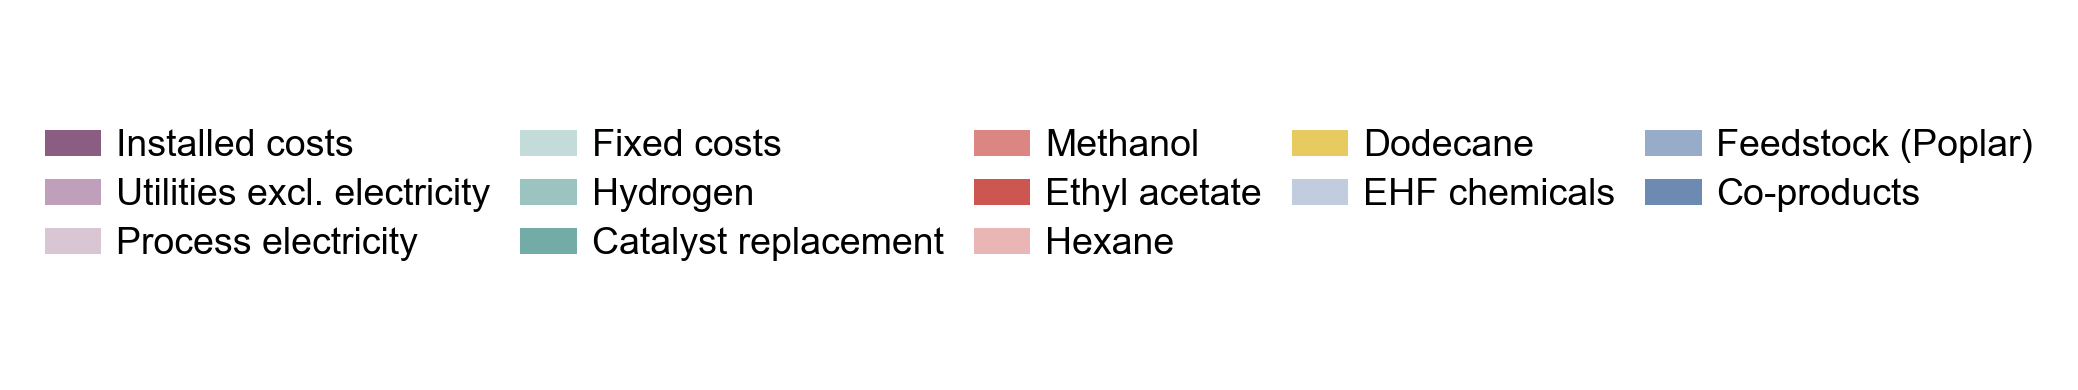

In [3]:
# ── Standalone legend figure ──────────────────────────────────────────────────
# Uses legend_categories and custom_colors defined above — keep in sync.
import matplotlib.patches as mpatches

patches = [
    mpatches.Patch(facecolor=color, label=label, edgecolor='none')
    for color, label in zip(custom_colors, legend_categories)
]

fig_leg, ax_leg = plt.subplots(figsize=(7.0, 1.4))

legend = ax_leg.legend(
    handles=patches,
    loc='center',
    ncol=5,
    frameon=False,
    fontsize=9,
    handlelength=1.5,
    handletextpad=0.4,
    columnspacing=0.8,
    labelspacing=0.4,
)

for text in legend.get_texts():
    text.set_bbox(None)

ax_leg.axis('off')
plt.tight_layout()
plt.savefig('legend_breakdown.svg', bbox_inches='tight')
plt.show()

In [4]:
F.BT.results()

Boiler turbogenerator                                      Units        BT
Electricity           Power                                   kW -2.83e+04
                      Cost                                USD/hr -2.34e+03
Medium pressure steam Duty                                 kJ/hr  -1.1e+07
                      Flow                               kmol/hr      -305
                      Cost                                USD/hr       -84
High pressure steam   Duty                                 kJ/hr -8.53e+08
                      Flow                               kmol/hr -2.65e+04
                      Cost                                USD/hr -8.41e+03
Natural gas           Duty                                 kJ/hr -1.99e+08
                      Flow                               kmol/hr      -295
                      Cost                                USD/hr -1.03e+03
Low pressure steam    Duty                                 kJ/hr -1.28e+09
                      Flow                               kmol/hr  -3.3e+04
                      Cost                                USD/hr -7.85e+03
Cooling water         Duty                                 kJ/hr -2.22e+07
                      Flow                               kmol/hr  1.51e+04
                      Cost                                USD/hr      7.38
Fuel (inlet)          Flow                                 kg/hr  4.29e+04
                      Cost                                USD/hr  7.88e+03
Ash disposal (outlet) Flow                                 kg/hr  1.41e+03
                      Cost                                USD/hr      44.7
Design                Work                                    kW  3.49e+04
                      Flow rate                            kg/hr  1.15e+06
                      Ash disposal                         kg/hr  1.41e+03
Purchase cost         Baghouse bags                          USD  2.29e+05
                      Boiler                                 USD  1.12e+08
                      Deaerator                              USD   1.2e+06
                      Amine addition pkg                     USD  1.58e+05
                      Hot process water softener system      USD  3.08e+05
                      Turbogenerator                         USD  1.29e+07
Total purchase cost                                          USD  1.27e+08
Utility cost                                              USD/hr -1.18e+04